# Notebook 3 — Modelagem Preditiva e Projeção para 2026

Objetivo:
Avaliar o potencial preditivo das variáveis temporais e político-eleitorais desenvolvidas na Camada Ouro do Lakehouse, além de gerar uma projeção preliminar para os gastos públicos federais em 2026.

In [92]:
# Instalação das bibliotecas
%pip install duckdb pandas numpy scikit-learn xgboost pyarrow matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [93]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [94]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

In [95]:
# Conexão com o Lakehouse
con = duckdb.connect("../duckdb/lakehouse.duckdb", read_only=True)
print("Conexão com o Lakehouse estabelecida com sucesso!")

Conexão com o Lakehouse estabelecida com sucesso!


## 1. Carregamento da Base Analítica

Será utilizada a tabela ouro.despesas_por_orgao, que concentra os atributos históricos, temporais e político-eleitorais desenvolvidos ao longo do projeto.

In [96]:
df = con.sql("""

SELECT *
FROM ouro.despesas_por_orgao
WHERE ano < 2026
""").df()

df.head()

,sk_despesa_orgao,ano,codigo_orgao,nome_orgao,codigo_orgao_superior,nome_orgao_superior,pacote,fl_ano_pre_eleitoral,fl_ano_pos_eleitoral,fl_ano_eleitoral,...,governo,valor_empenhado,valor_liquidado,valor_pago,valor_pago_lag_1,valor_pago_lag_2,valor_pago_lag_3,variacao_yoy_abs,variacao_yoy_pct,rolling_mean_3
0,450da66cdd88544156ab378cd673bb0a,2014,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,False,False,True,...,Dilma 1,2.270970e+09,1.754617e+09,1.641083e+09,NaN,NaN,NaN,NaN,NaN,NaN
1,75811a90e753b3d2d1d02f9ed39a04df,2015,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,True,False,False,...,Dilma 2,1.912447e+09,1.592726e+09,1.560976e+09,1.641083e+09,NaN,NaN,-8.010742e+07,-4.88,1.641083e+09
2,822aa769d14119fb896e733dee9261ef,2016,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,False,False,True,...,Transicao,2.110212e+09,1.694061e+09,1.669952e+09,1.560976e+09,1.641083e+09,NaN,1.089761e+08,6.98,1.601029e+09
3,e7d8ec9352f8c85490e7f5753347f993,2017,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,False,True,False,...,Temer,2.414102e+09,1.776560e+09,1.775814e+09,1.669952e+09,1.560976e+09,1.641083e+09,1.058622e+08,6.34,1.624003e+09
4,c117f22822d19ba1952c5400f09c0ad3,2018,22204,Departamento Nacional de Obras Contra as Secas,53000,Ministério da Integração e do Desenvolvimento ...,infraestrutura,False,False,True,...,Temer,2.322628e+09,1.680759e+09,1.568180e+09,1.775814e+09,1.669952e+09,1.560976e+09,-2.076341e+08,-11.69,1.668914e+09


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2185 entries, 0 to 2184
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sk_despesa_orgao       2185 non-null   str    
 1   ano                    2185 non-null   int32  
 2   codigo_orgao           2185 non-null   str    
 3   nome_orgao             2185 non-null   str    
 4   codigo_orgao_superior  2185 non-null   str    
 5   nome_orgao_superior    2185 non-null   str    
 6   pacote                 2185 non-null   str    
 7   fl_ano_pre_eleitoral   2185 non-null   bool   
 8   fl_ano_pos_eleitoral   2185 non-null   bool   
 9   fl_ano_eleitoral       2185 non-null   bool   
 10  tipo_eleicao           2185 non-null   str    
 11  governo                2185 non-null   str    
 12  valor_empenhado        2185 non-null   float64
 13  valor_liquidado        2185 non-null   float64
 14  valor_pago             2185 non-null   float64
 15  valor_pago_lag_

## 2. Seleção das Variáveis

As variáveis foram agrupadas em três categorias:

- Temporais
- Político-eleitorais
- Estruturais

In [98]:
features_historicas = [
    "ano",
    "valor_pago_lag_1",
    "valor_pago_lag_2",
    "valor_pago_lag_3",
    "rolling_mean_3"
]

features_politicas = [
    "fl_ano_eleitoral",
    "fl_ano_pre_eleitoral",
    "fl_ano_pos_eleitoral",
    "tipo_eleicao",
    "governo"
]

features_estruturais = [
    "pacote"
]

## 3. Preparação dos Dados

Os registros contendo valores nulos nas variáveis temporais foram removidos para garantir consistência durante o treinamento.

In [99]:
target = "valor_pago"

features = (
    features_historicas
    + features_politicas
    + features_estruturais
)

df_modelo = (
    df[
        features + [target]
    ]
    .dropna()
    .copy()
)

print(f"Quantidade de registros: {df_modelo.shape[0]:,}")
print(f"Quantidade de colunas: {df_modelo.shape[1]}")

Quantidade de registros: 1,612
Quantidade de colunas: 12


## 4. Separação Temporal

Diferentemente da divisão aleatória tradicional (80/20), foi utilizada uma divisão cronológica.

Treino:
2017–2023

Teste:
2024–2025

Essa abordagem evita vazamento temporal e simula o cenário real de previsão para 2026.

In [100]:
train = (
    df_modelo[
        df_modelo["ano"] <= 2023
    ]
    .copy()
)

test = (
    df_modelo[
        df_modelo["ano"] >= 2024
    ]
    .copy()
)

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (1250, 11)
Teste:  (362, 11)


In [101]:
print(
    "Anos treino:",
    sorted(train["ano"].unique())
)

print(
    "Anos teste:",
    sorted(test["ano"].unique())
)

Anos treino: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]
Anos teste: [np.int32(2024), np.int32(2025)]


### Separação Temporal dos Dados

Diferentemente de problemas tradicionais de classificação, modelos de previsão temporal não devem utilizar amostragem aleatória para treino e teste.

A divisão cronológica preserva a ordem dos eventos e simula o cenário real de previsão, onde informações futuras não estão disponíveis durante o treinamento.

Assim, o modelo foi treinado utilizando observações de 2017 a 2023 e validado nos anos de 2024 e 2025.

## 5. Comparação de Conjuntos de Variáveis

Serão avaliados dois cenários:

Modelo A:
Apenas histórico.

Modelo B:
Histórico + variáveis político-eleitorais.

### 5.1 Modelo A — Histórico

O primeiro experimento utiliza exclusivamente informações históricas das despesas públicas.

O objetivo é avaliar o quanto a dinâmica temporal dos gastos é capaz de explicar os valores futuros sem considerar variáveis político-eleitorais.

In [102]:
features_a = (
    features_historicas
    + features_estruturais
)

cat_features_a = [
    "pacote"
]

num_features_a = [
    "valor_pago_lag_1",
    "valor_pago_lag_2",
    "valor_pago_lag_3",
    "rolling_mean_3"
]

preprocessor_a = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features_a
        ),
        (
            "num",
            "passthrough",
            num_features_a
        )
    ]
)

modelo_a = Pipeline(
    steps=[
        ("preprocessor", preprocessor_a),
        ("regressor", LinearRegression())
    ]
)

modelo_a.fit(
    X_train[features_a],
    y_train
)

pred_a = modelo_a.predict(
    X_test[features_a]
)

In [103]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2_a = r2_score(
    y_test,
    pred_a
)

mae_a = mean_absolute_error(
    y_test,
    pred_a
)

rmse_a = (
    mean_squared_error(
        y_test,
        pred_a
    ) ** 0.5
)

print(f"R²:   {r2_a:.4f}")
print(f"MAE:  {mae_a:,.0f}")
print(f"RMSE: {rmse_a:,.0f}")

R²:   0.9989
MAE:  1,798,572,131
RMSE: 13,271,988,014


### 5.2 Modelo B — Histórico + Variáveis Político-Eleitorais

O segundo experimento incorpora as variáveis desenvolvidas na camada Ouro relacionadas ao ciclo político-eleitoral.

O objetivo é verificar se informações sobre anos eleitorais, governos e tipo de eleição aumentam a capacidade preditiva do modelo.

In [104]:
features_b = (
    features_historicas
    + features_politicas
    + features_estruturais
)

cat_features_b = [
    "tipo_eleicao",
    "governo",
    "pacote"
]

num_features_b = [
    "valor_pago_lag_1",
    "valor_pago_lag_2",
    "valor_pago_lag_3",
    "rolling_mean_3",
    "fl_ano_eleitoral",
    "fl_ano_pre_eleitoral",
    "fl_ano_pos_eleitoral"
]

preprocessor_b = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features_b
        ),
        (
            "num",
            "passthrough",
            num_features_b
        )
    ]
)

modelo_b = Pipeline(
    steps=[
        ("preprocessor", preprocessor_b),
        ("regressor", LinearRegression())
    ]
)

modelo_b.fit(
    X_train[features_b],
    y_train
)

pred_b = modelo_b.predict(
    X_test[features_b]
)

In [105]:
r2_b = r2_score(
    y_test,
    pred_b
)

mae_b = mean_absolute_error(
    y_test,
    pred_b
)

rmse_b = (
    mean_squared_error(
        y_test,
        pred_b
    ) ** 0.5
)

print(f"R²:   {r2_b:.4f}")
print(f"MAE:  {mae_b:,.0f}")
print(f"RMSE: {rmse_b:,.0f}")

R²:   0.9989
MAE:  1,798,572,131
RMSE: 13,271,988,014


## 7. Comparação dos Resultados

Os dois modelos são comparados para avaliar se as variáveis político-eleitorais agregam poder preditivo além das informações históricas.

In [106]:
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Histórico",
        "Histórico + Política"
    ],
    "R2": [
        r2_a,
        r2_b
    ],
    "MAE": [
        mae_a,
        mae_b
    ],
    "RMSE": [
        rmse_a,
        rmse_b
    ]
})

comparacao_modelos

,Modelo,R2,MAE,RMSE
0,Histórico,0.998907,1.798572e+09,1.327199e+10
1,Histórico + Política,0.998907,1.798572e+09,1.327199e+10


### Interpretação dos Resultados

Os resultados indicam que a inclusão das variáveis político-eleitorais não produziu ganho relevante de desempenho preditivo.

O Modelo A (Histórico) e o Modelo B (Histórico + Política) apresentaram métricas praticamente idênticas de R², MAE e RMSE.

Isso sugere que a dinâmica histórica das despesas públicas, representada pelas variáveis de defasagem temporal (`valor_pago_lag_1`, `valor_pago_lag_2`, `valor_pago_lag_3`) e pela média móvel (`rolling_mean_3`), já captura a maior parte da variabilidade observada nos dados.

Ainda que não tenham aumentado a capacidade preditiva do modelo, as variáveis político-eleitorais permanecem relevantes para a interpretação substantiva dos resultados e para a análise dos ciclos de gasto em diferentes contextos governamentais.

## 8. Importância das Variáveis

Para interpretar a contribuição individual de cada atributo foi treinado um modelo Random Forest.

O objetivo não é substituir o modelo principal, mas compreender quais variáveis possuem maior influência sobre as previsões.

In [107]:
from sklearn.ensemble import RandomForestRegressor

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features_b
        ),
        (
            "num",
            "passthrough",
            num_features_b
        )
    ]
)

modelo_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_rf
        ),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

modelo_rf.fit(
    X_train[features_b],
    y_train
)

pred_rf = modelo_rf.predict(
    X_test[features_b]
)

In [108]:
r2_rf = r2_score(
    y_test,
    pred_rf
)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

rmse_rf = (
    mean_squared_error(
        y_test,
        pred_rf
    ) ** 0.5
)

pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Random Forest"
    ],
    "R2": [
        r2_b,
        r2_rf
    ],
    "MAE": [
        mae_b,
        mae_rf
    ],
    "RMSE": [
        rmse_b,
        rmse_rf
    ]
})

,Modelo,R2,MAE,RMSE
0,Regressão Linear,0.998907,1.798572e+09,1.327199e+10
1,Random Forest,0.977145,7.110291e+09,6.068759e+10


### Interpretação do Random Forest

Embora o Random Forest seja capaz de capturar relações não lineares, seu desempenho foi inferior ao da Regressão Linear.

Esse resultado sugere que a série histórica apresenta comportamento predominantemente linear e altamente dependente das observações passadas, favorecendo modelos mais simples e interpretáveis.

In [109]:
feature_names = (
    modelo_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importancias = (
    modelo_rf
    .named_steps["regressor"]
    .feature_importances_
)

df_importancia = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importancias
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

df_importancia.head(10)

,feature,importance
10,num__valor_pago_lag_2,0.268263
12,num__rolling_mean_3,0.255434
9,num__valor_pago_lag_1,0.233005
11,num__valor_pago_lag_3,0.225471
8,cat__pacote_nucleo_eleitoral,0.005998
6,cat__pacote_coordenacao_politica,0.004344
1,cat__tipo_eleicao_Municipal,0.002344
5,cat__governo_Temer,0.001613
3,cat__governo_Bolsonaro,0.000808
4,cat__governo_Lula 3,0.000655


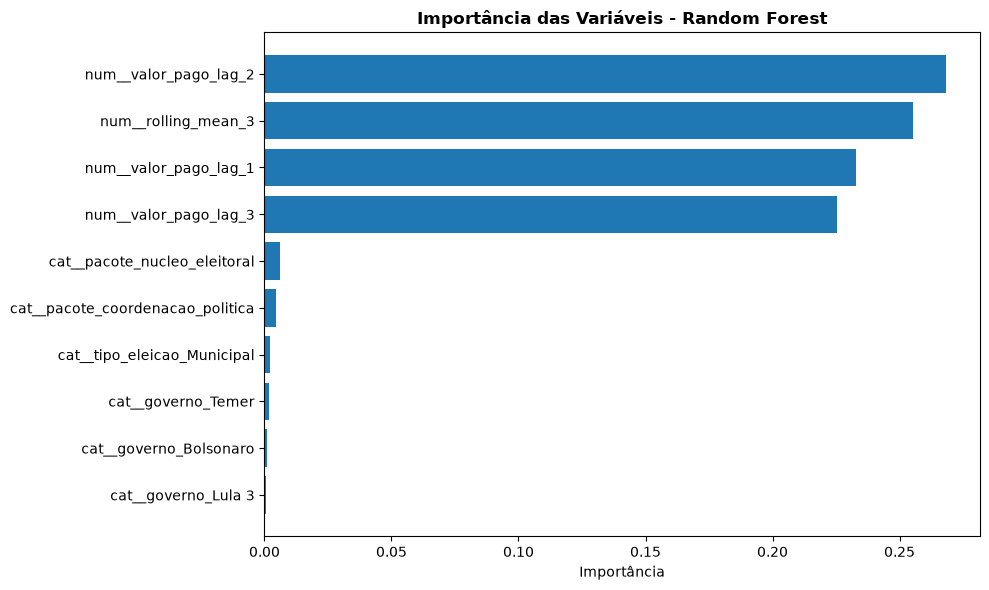

In [110]:
plt.figure(figsize=(10, 6))

top_features = (
    df_importancia
    .head(10)
    .sort_values("importance")
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(
    "Importância das Variáveis - Random Forest",
    fontweight="bold"
)

plt.xlabel("Importância")

plt.tight_layout()

plt.show()

### Principais Variáveis Explicativas

As variáveis de maior importância foram:

- valor_pago_lag_1
- valor_pago_lag_2
- valor_pago_lag_3
- rolling_mean_3

As variáveis político-eleitorais apresentaram contribuição marginal para o desempenho preditivo.

Esse resultado reforça que o comportamento dos gastos públicos possui elevada persistência temporal.

## 9. Modelo Final

Como a Regressão Linear apresentou o melhor desempenho durante a validação temporal, ela será utilizada para gerar as projeções para o exercício de 2026.

In [111]:
features_finais = features_b

modelo_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_b),
        ("regressor", LinearRegression())
    ]
)

modelo_final.fit(
    df_modelo[features_finais],
    df_modelo[target]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['ano','valor_pago_lag_1','valor_pago_lag_2',...,'tipo_eleicao','governo', 'pacote']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

### 9.1Projeção das Despesas para 2026

Após a seleção do modelo final, foi construída uma base sintética para o exercício de 2026.

Como não existem registros observados para esse ano na base histórica, os atributos temporais foram derivados dos valores efetivamente observados entre 2023 e 2025.

Além disso, foram incorporadas as características político-institucionais previstas para 2026, incluindo a classificação como ano eleitoral geral e a continuidade do governo vigente.

A partir dessa base, o modelo estimará o comportamento esperado das despesas públicas federais para o exercício de 2026.

In [112]:
base_2026 = (
    df[df["ano"] == 2025]
    .copy()
)

base_2026["ano"] = 2026
base_2026["fl_ano_eleitoral"] = True
base_2026["fl_ano_pre_eleitoral"] = False
base_2026["fl_ano_pos_eleitoral"] = False
base_2026["tipo_eleicao"] = "Geral"
base_2026["governo"] = "Lula 3"

In [113]:
base_2026 = base_2026.dropna(
    subset=[
        "valor_pago_lag_1",
        "valor_pago_lag_2",
        "valor_pago_lag_3",
        "rolling_mean_3"
    ]
)

print(base_2026.shape)

(181, 21)


In [114]:
X_2026 = base_2026[
    features_finais
]

X_2026.isnull().sum()

ano                     0
valor_pago_lag_1        0
valor_pago_lag_2        0
valor_pago_lag_3        0
rolling_mean_3          0
fl_ano_eleitoral        0
fl_ano_pre_eleitoral    0
fl_ano_pos_eleitoral    0
tipo_eleicao            0
governo                 0
pacote                  0
dtype: int64

In [115]:
pred_2026 = modelo_final.predict(
    X_2026
)

pred_2026[:10]

array([2.18820665e+09, 4.86037751e+09, 3.66966231e+09, 8.55804196e+08,
       8.10585241e+08, 1.43235958e+09, 7.82588322e+08, 5.66271974e+08,
       3.20309607e+09, 2.94083771e+08])

In [116]:
base_2026["valor_pago_previsto"] = pred_2026

base_2026["valor_pago_previsto"] = (
    base_2026["valor_pago_previsto"]
    .clip(lower=0)
)

In [117]:
base_2026["valor_pago_previsto"].describe()

count    1.810000e+02
mean     4.996518e+10
std      4.215353e+11
min      2.081564e+08
25%      8.697026e+08
50%      1.483845e+09
75%      3.495512e+09
max      5.351121e+12
Name: valor_pago_previsto, dtype: float64

In [118]:
projecao_pacotes = (
    base_2026
    .groupby(
        "pacote",
        as_index=False
    )["valor_pago_previsto"]
    .sum()
    .sort_values(
        "valor_pago_previsto",
        ascending=False
    )
)

projecao_pacotes

,pacote,valor_pago_previsto
0,coordenacao_politica,5.463402e+12
2,nucleo_eleitoral,3.285561e+12
1,infraestrutura,2.947335e+11


In [119]:
historico_pacotes = (
    df.groupby(
        ["ano", "pacote"],
        as_index=False
    )["valor_pago"]
    .sum()
)

projecao_2026 = (
    base_2026
    .groupby(
        "pacote",
        as_index=False
    )["valor_pago_previsto"]
    .sum()
)

projecao_2026["ano"] = 2026

projecao_2026 = projecao_2026.rename(
    columns={
        "valor_pago_previsto": "valor_pago"
    }
)

df_plot = pd.concat(
    [
        historico_pacotes,
        projecao_2026
    ],
    ignore_index=True
)

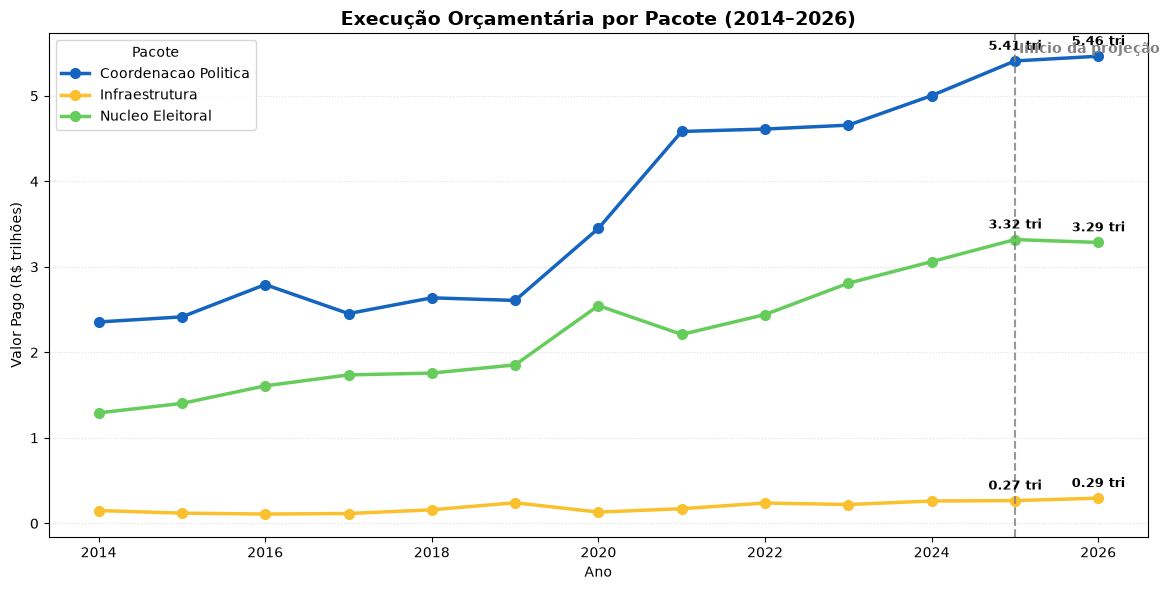

In [120]:
plt.figure(figsize=(12, 6))

cores = {
    "coordenacao_politica": "#1565C0",  # Azul
    "nucleo_eleitoral": "#66CC5C",      # Verde
    "infraestrutura": "#FBC02D"         # Amarelo
}

for pacote in df_plot["pacote"].unique():

    dados = (
        df_plot[df_plot["pacote"] == pacote]
        .sort_values("ano")
    )

    # Converter para trilhões
    y = dados["valor_pago"] / 1e12

    plt.plot(
        dados["ano"],
        y,
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=cores[pacote],
        label=pacote.replace("_", " ").title()
    )

    # Destacar apenas 2025 e 2026
    for _, row in dados[dados["ano"].isin([2025, 2026])].iterrows():

        valor = row["valor_pago"] / 1e12

        plt.annotate(
            f"{valor:.2f} tri",
            (row["ano"], valor),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

# Linha que separa histórico e projeção
plt.axvline(
    2025,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Texto da projeção
ylim = plt.ylim()

plt.annotate(
    "Início da projeção",
    xy=(2025.05, ylim[1] * 0.96),
    fontsize=10,
    fontweight="bold",
    color="gray"
)

plt.title(
    "Execução Orçamentária por Pacote (2014–2026)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Ano")

plt.ylabel(
    "Valor Pago (R$ trilhões)"
)

plt.legend(
    title="Pacote"
)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [121]:
comparacao = (
    df_plot[
        df_plot["ano"].isin([2025, 2026])
    ]
    .pivot(
        index="pacote",
        columns="ano",
        values="valor_pago"
    )
)

comparacao = comparacao / 1e12

comparacao

ano,2025,2026
pacote,,
coordenacao_politica,5.408354,5.463402
infraestrutura,0.265865,0.294734
nucleo_eleitoral,3.319116,3.285561


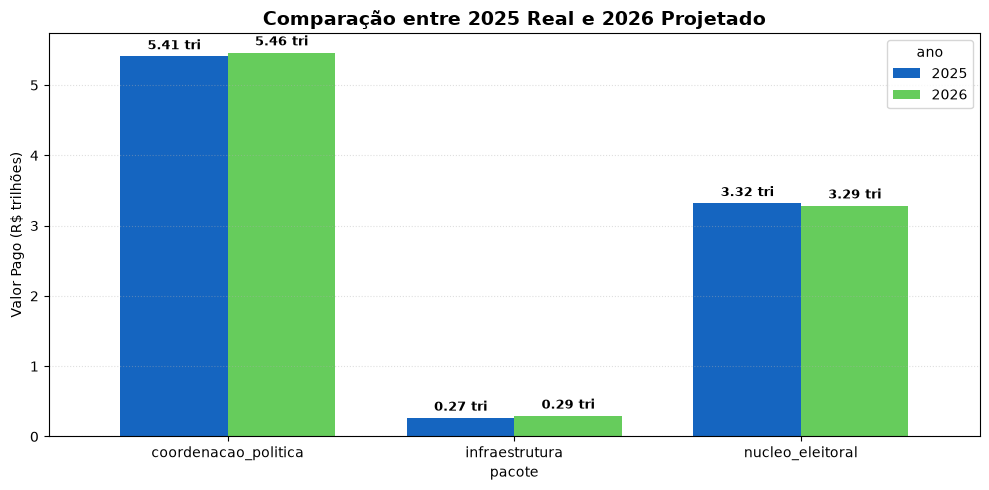

In [122]:
ax = comparacao.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#1565C0", "#66CC5C"],
    width=0.75
)

plt.title(
    "Comparação entre 2025 Real e 2026 Projetado",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Valor Pago (R$ trilhões)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f tri",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Interpretação da Projeção para 2026

A projeção indica continuidade dos padrões observados nos últimos exercícios fiscais.

Os grupos de Coordenação Política e Infraestrutura apresentam crescimento moderado em relação a 2025, refletindo a persistência das tendências históricas identificadas ao longo da série temporal.

Já o Núcleo Eleitoral mantém patamar semelhante ao observado em 2025, sem expansão relevante, sugerindo que os efeitos políticos observados nas análises exploratórias já estão incorporados ao comportamento histórico dos gastos.

Os resultados reforçam a conclusão obtida durante a comparação dos modelos: a dinâmica temporal das despesas públicas exerce influência significativamente maior sobre a capacidade preditiva do que as variáveis político-eleitorais isoladamente.

# 10. Conclusões

Os resultados demonstram que os gastos públicos federais apresentam forte dependência temporal, permitindo elevada capacidade preditiva a partir de informações históricas.

Embora as variáveis político-eleitorais tenham apresentado baixa contribuição incremental para o desempenho dos modelos, elas permanecem relevantes para interpretação do contexto institucional e análise dos ciclos de governo.

A projeção para 2026 sugere continuidade da trajetória observada nos últimos anos, com manutenção do protagonismo dos pacotes de Coordenação Política e Núcleo Eleitoral no volume total de despesas.